# Tutorial: Random Directions algorithm x PyPSA

In [1]:
import pandas as pd
import pypsa
import yaml

from mga4all.examples import create_pypsa_network

## 1. Load example PyPSA model

In [2]:
# Load example PyPSA model that the config refers to
n = create_pypsa_network()

INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


In [4]:
# Set the desired solver options
pypsa.options.params.optimize.solver_name = "gurobi"
pypsa.options.params.optimize.solver_options = {
    'Method': 2,  # Use the barrier algorithm
    'Crossover': 0,
}

In [5]:
# Find cost-optimal solution
n.optimize(log_to_console=False);

/tmp/ipykernel_92891/2238090962.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(log_to_console=False);
Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False
INFO:linopy.io: Writing time: 0.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2026-08-25


INFO:gurobipy:Academic license - for non-commercial use only - expires 2026-08-25


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Linux Mint 22")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i7-10610U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 688 rows, 296 columns and 1324 nonzeros
INFO:gurobipy:Model fingerprint: 0xd41ae2e6
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 5e+00]
INFO:gurobipy:  Objective range  [4e+02, 2e+03]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 1e+03]
INFO:gurobipy:Presolve removed 124 rows and 332 columns
INFO:gurobipy:Presolve time: 0.01s
INFO:gurobipy:Presolved: 172 rows, 356 columns, 1572 nonzeros


## 2. Generate alternative solutions with random-direction MGA

### 2.1 Load and check MGA configuration

In [6]:
from mga4all.validate import RandomDirectionsConfig

# Load configuration file
with open("../../configs/test_config_random_directions.yaml") as yf:
    test_config = RandomDirectionsConfig.model_validate(yaml.safe_load(yf))

In [7]:
# Check that it reflects the desired setup
test_config

{'config_name': 'random_directions',
 'model_interface': 'pypsa',
 'cost_slack': 0.1,
 'alternatives': 5,
 'spatially_explicit': False,
 'diversified_technologies': ['wind', 'solar', 'gas', 'battery']}

### 2.2 Import algorithm and run

In [8]:
from mga4all.mga_random_directions import random_directions_algorithm

In [9]:
mga_alternatives, mga_spatial_alternatives = random_directions_algorithm(test_config, n)

Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False


Technologies [] not found in the model


INFO:linopy.io: Writing time: 0.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Linux Mint 22")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i7-10610U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 689 rows, 296 columns and 1332 nonzeros
INFO:gurobipy:Model fingerprint: 0x91ac36a5
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 2e+03]
INFO:gurobipy:  Objective range  [3e-01, 5e-01]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 7e+05]
INFO:gurobipy:Presolve removed 124 rows and 334 columns
INFO:gurobipy:Presolve time: 0.01s
INFO:gurobipy:Presolved: 172 rows, 355 columns, 1578 nonzeros


### 2.3 Inspect the alternatives

In [ ]:
mga_total_capacities = pd.concat((
    pd.DataFrame(mga_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

mga_spatial_capacities = pd.concat((
    pd.DataFrame(mga_spatial_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

<Axes: >

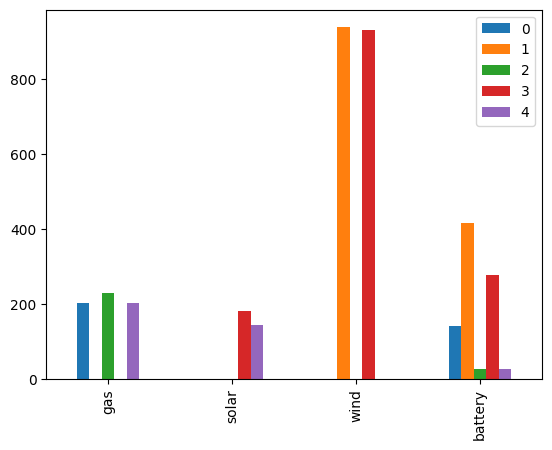

In [11]:
mga_total_capacities.plot.bar()

<Axes: >

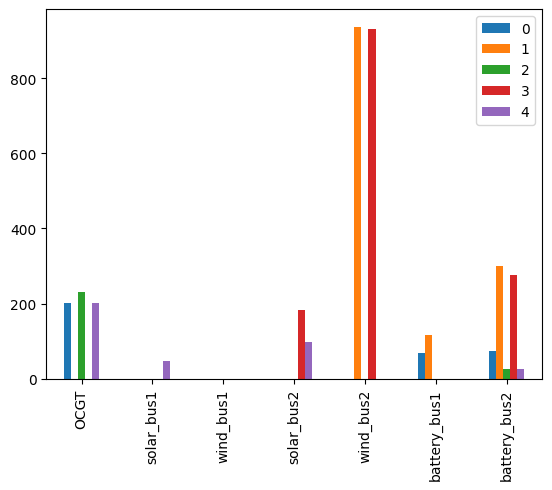

In [12]:
mga_spatial_capacities.plot.bar()